In [1]:
import numpy as np
import matplotlib.pyplot as plt
from forTP1 import Bandit

myBandit = Bandit()

#### Uniform Exploration

In [35]:
def Uniform_Exploration(K, T, N, plot=False):
    bandits = [[]]
    for k in range(K-1):
        bandits.append([]) 

    for n in range(N):
        for k in range(K):
            reward = myBandit.get_arm(k)
            bandits[k].append(reward)

    averages = [np.mean(sub_array) for sub_array in bandits]
    bestk = np.argmax(averages)
    

    for t in range(T-(K*N)):
        reward = myBandit.get_arm(bestk)
        bandits[bestk].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]


    if plot == True:
        print(f"Averages = {averages}")
        print(f"Best arm = {bestk}")
        print(f"Sums = {summs}")
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()
        
        fig2 = plt.figure()
        for k in range(K):
            if len(bandits[k]) > 1:
                averages = [np.mean(bandits[k][:i+1]) for i in range(len(bandits[k]))]
                plt.plot(range(1, len(averages) + 1), averages, label=f'Bandit {k}', alpha=0.8)
        
        plt.xlabel('Number of Pulls')
        plt.ylabel('Average Reward')
        plt.title('Average Reward Evolution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return np.sum(summs)/T

    

Averages = [np.float64(9.8), np.float64(12.7), np.float64(6.82), np.float64(12.2), np.float64(11.1), np.float64(12.2), np.float64(9.78), np.float64(9.52), np.float64(9.46), np.float64(9.04)]
Best arm = 1
Sums = [np.int32(490), np.int32(7161), np.int32(341), np.int32(610), np.int32(555), np.int32(610), np.int32(489), np.int32(476), np.int32(473), np.int32(452)]


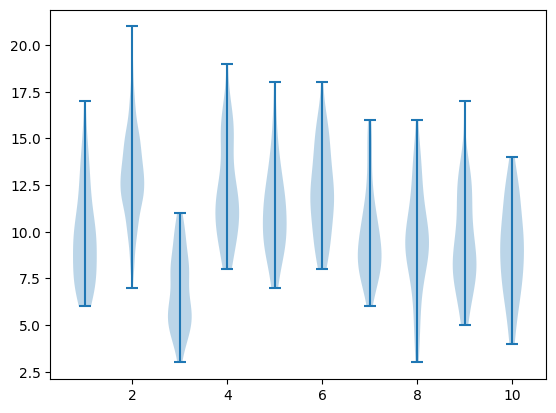

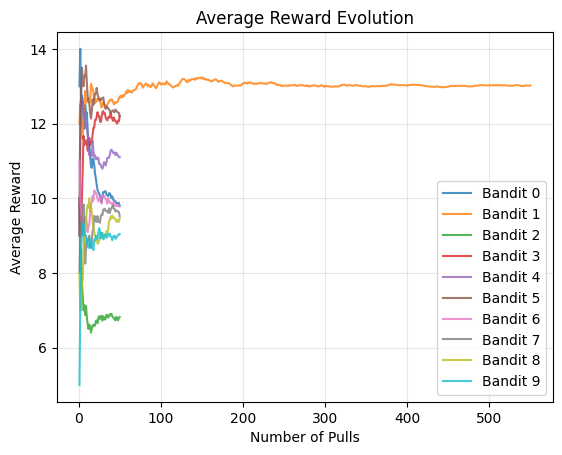

In [5]:
K = 10
T = 1000
N = 50
reward = Uniform_Exploration(K, T, N, True)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We observe that the algorithm explores all the arms as expected before deciding which one is the best.
  </p>
</div>

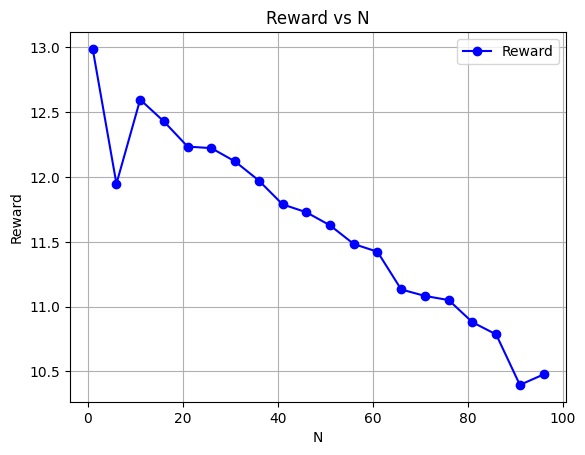

In [6]:
N_values = range(1, 100, 5)
reward_values = []

for N in N_values:
    reward = Uniform_Exploration(K, T, N)  
    reward_values.append(reward)  

plt.plot(N_values, reward_values, marker='o', linestyle='-', color='b', label='Reward')
plt.xlabel('N')
plt.ylabel('Reward')
plt.title('Reward vs N')
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    After testing multiple values of N, we can see that this hyperparameter seems to decrease the average reward, meaning that the exploration of multiple arms is not valuable for long.
  </p>
</div>

#### ε-Greedy

In [8]:
def Ep_Greedy(K, T, Epsilon, plot = False):
    bandits = [[]]
    for k in range(K-1):
        bandits.append([]) 

    for t in range(T):

        if np.random.uniform(0, 1) > Epsilon:
            meds = [np.average(sub_array) for sub_array in bandits]
            k = np.argmax(meds)
            
        else:
            k = np.random.randint(0,K)
        
        reward = myBandit.get_arm(k)
        bandits[k].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]

    if plot == True:
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()
        
        fig2 = plt.figure()
        for k in range(K):
            if len(bandits[k]) > 1:
                averages = [np.mean(bandits[k][:i+1]) for i in range(len(bandits[k]))]
                plt.plot(range(1, len(averages) + 1), averages, label=f'Bandit {k}', alpha=0.8)
        
        plt.xlabel('Number of Pulls')
        plt.ylabel('Average Reward')
        plt.title('Average Reward Evolution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return np.sum(summs)/T

c:\Users\ferna\.virtualenvs\TPs_Univ-6thOmQNe\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\ferna\.virtualenvs\TPs_Univ-6thOmQNe\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


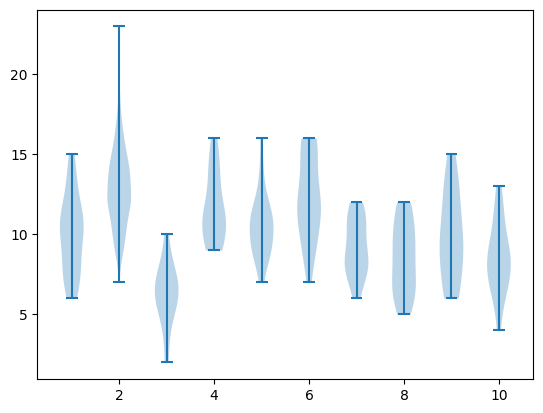

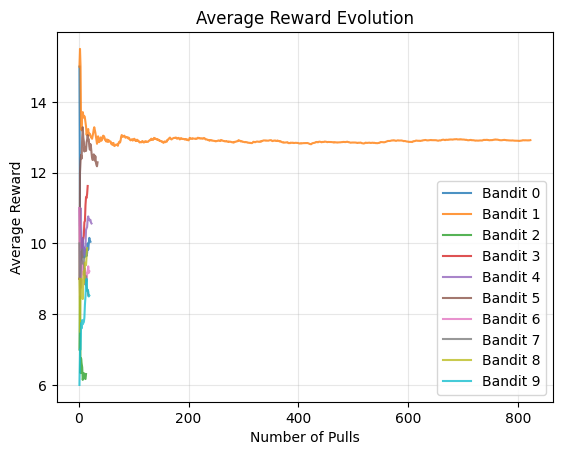

In [9]:
Epsilon = 0.2
reward = Ep_Greedy(K, T, Epsilon, True)

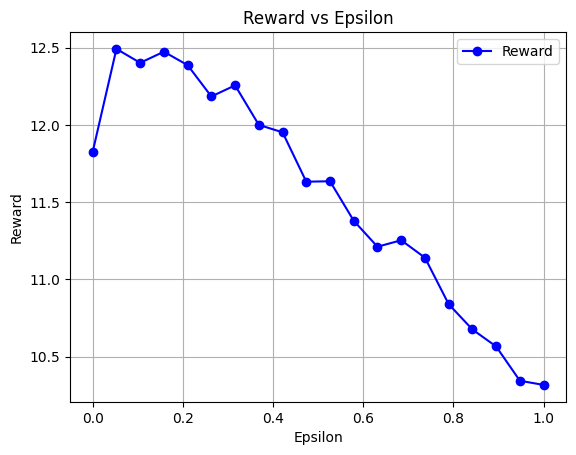

In [14]:
Ep_values = np.linspace(0, 1, 20)
reward_values = []

for ep in Ep_values:
    reward = Ep_Greedy(K, T, ep)  
    reward_values.append(reward)  

plt.plot(Ep_values, reward_values, marker='o', linestyle='-', color='b', label='Reward')
plt.xlabel('Epsilon')
plt.ylabel('Reward')
plt.title('Reward vs Epsilon')
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Simmilarly to the previous algorithm, increasing the value of the hyperparameter, Epsilon in this case, cause a decrease in the reward value, probably due to a high regret cost for exploration in this scenario.
  </p>
</div>

#### Successive Elimination

In [36]:
def Adaptive_Elimination(K, T, plot = False):

    active_bandits = list(range(K))
    total_pulls = 0
    bandits = [[]]
    for k in range(K-1):
        bandits.append([])
    
    while total_pulls < T and len(active_bandits) > 1:
        # Play each active bandit once
        for k in active_bandits:
            if total_pulls >= T:
                break
            reward = myBandit.get_arm(k)
            bandits[k].append(reward)
            total_pulls += 1
        
        # Check for elimination after sufficient samples
        if total_pulls >= 2 * K:
            bounds = {}
            for k in active_bandits:
                if len(bandits[k]) >= 2:
                    mean_val = np.mean(bandits[k])
                    std_val = np.std(bandits[k], ddof=1)
                    n = len(bandits[k])
                    # sem = std_val / np.sqrt(n)
                    bounds[k] = (mean_val - std_val, mean_val + std_val)
            
            if bounds:
                best_lower = max(lower for lower, upper in bounds.values())
                to_remove = [k for k in bounds if bounds[k][1] < best_lower]
                active_bandits = [k for k in active_bandits if k not in to_remove]
    
    # Use the best bandit for remaining pulls
    if active_bandits and total_pulls < T:
        best_k = active_bandits[0]
        for _ in range(T - total_pulls):
            reward = myBandit.get_arm(best_k)
            bandits[best_k].append(reward)
    
    total_reward = sum(sum(r) for r in bandits)
    
    if plot == True:
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()
        
        fig2 = plt.figure()
        for k in range(K):
            if len(bandits[k]) > 1:
                averages = [np.mean(bandits[k][:i+1]) for i in range(len(bandits[k]))]
                plt.plot(range(1, len(averages) + 1), averages, label=f'Bandit {k}', alpha=0.8)
        
        plt.xlabel('Number of Pulls')
        plt.ylabel('Average Reward')
        plt.title('Average Reward Evolution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return total_reward / T

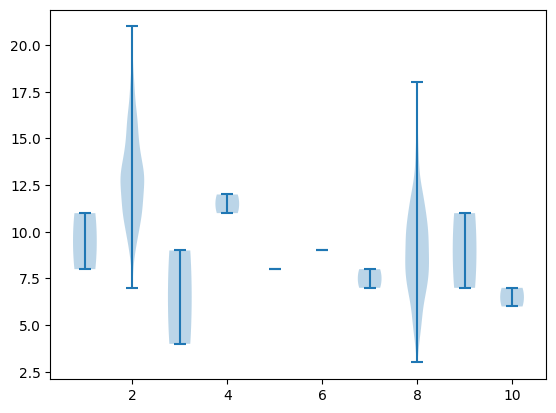

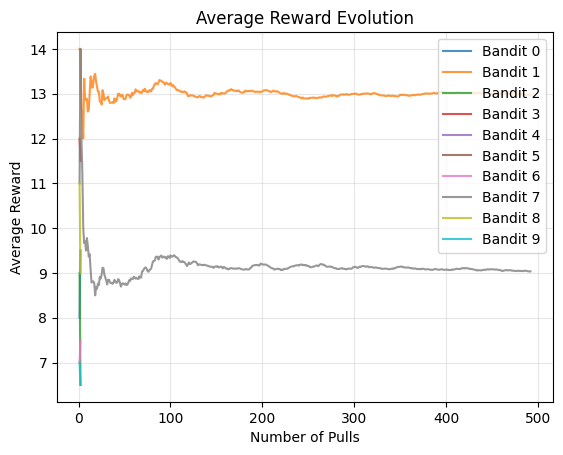

Average reward: 10.9590


In [58]:
reward = Adaptive_Elimination(K, T, plot=True)
print(f"Average reward: {reward:.4f}")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    As we can see, the algorithm was able to deactivate most of the less valueble arms quickly, with no great need to explore. But it sticked with two arms till the end, showing that it was unable to define the best one. The final reward is smaller compared with the previous algorithms.
  </p>
</div>

#### UCB1

In [ ]:
def UCB1(K, T, plot = False):
    
    bandits = [[]]
    for k in range(K-1):
        bandits.append([])
    cumulative_rewards = np.zeros(K)
    pull_counts = np.zeros(K, dtype=int)
    total_reward = 0
    ucb_values_history = []
    
    # Initialize each arm once
    for k in range(min(K, T)):
        reward = myBandit.get_arm(k)
        bandits[k].append(reward)
        pull_counts[k] += 1
        total_reward += reward
    
    # Main UCB1 loop
    for t in range(K, T):
        # Calculate UCB values
        current_ucb_values = {}
        ucb_values = np.zeros(K)
        for k in range(K):
            if pull_counts[k] == 0:
                ucb_values[k] = float('inf')
            else:
                mu_i = np.sum(bandits[k]) / pull_counts[k]
                exploration_term = np.sqrt(2 * np.log(t) / pull_counts[k])
                ucb_values[k] = mu_i + exploration_term
                
            current_ucb_values[k] = ucb_values[k]
            
        ucb_values_history.append(current_ucb_values.copy())
        
        # Select and pull arm
        selected_arm = np.argmax(ucb_values)
        reward = myBandit.get_arm(selected_arm)
        
        # Update statistics
        bandits[selected_arm].append(reward)
        pull_counts[selected_arm] += 1
        total_reward += reward
        
    if plot == True:
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()
        
        fig2 = plt.figure()
        for k in range(K):
            if len(bandits[k]) > 1:
                averages = [np.mean(bandits[k][:i+1]) for i in range(len(bandits[k]))]
                plt.plot(range(1, len(averages) + 1), averages, label=f'Bandit {k}', alpha=0.8)
        
        plt.xlabel('Number of Pulls')
        plt.ylabel('Average Reward')
        plt.title('Average Reward Evolution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        fig3 = plt.figure()
        time_steps = range(K, T)
        
        for k in range(K):
            ucb_vals = [ucb_values_history[t-K][k] for t in time_steps if k in ucb_values_history[t-K]]
            if ucb_vals:
                plt.plot(time_steps[:len(ucb_vals)], ucb_vals, 
                        label=f'Arm {k} UCB', alpha=0.8, linewidth=2)
        
        plt.xlabel('Time Step (t)')
        plt.ylabel('UCB Value')
        plt.title('UCB Values Evolution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return total_reward / T

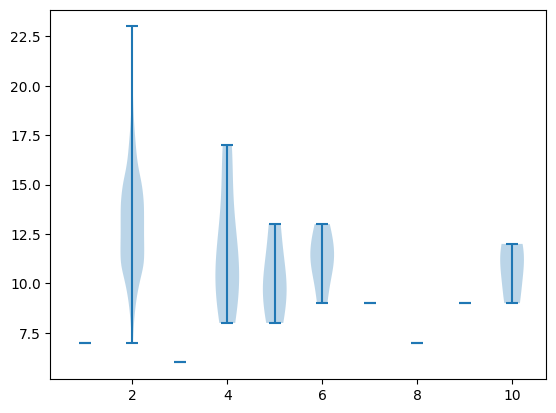

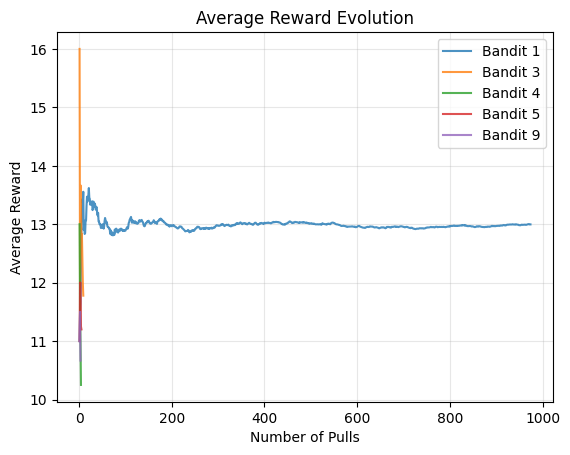

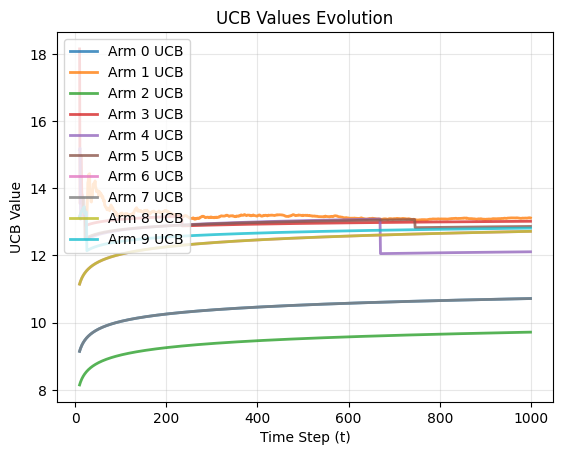

Average reward: 12.9320


In [ ]:
reward = UCB1(K, T, plot=True)
print(f"Average reward: {reward:.4f}")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see that this algorithm performed well, only exploring when it judges necessary after the increase of the UCB value over time for some of the arms, as the last picture shows. We can also see that after the exploration the UCB value quickly drops to reveal the truly most valuable arm.
  </p>
</div>

### Comparison

In [38]:
num_runs = 50  

results = {
    "Uniform_Exploration": [],
    "Ep_Greedy": [],
    "Adaptive_Elimination": [],
    "UCB1": []
}

for run in range(num_runs):
    r1 = Uniform_Exploration(K, T, N=10, plot=False)
    r2 = Ep_Greedy(K, T, Epsilon=0.1, plot=False)
    r3 = Adaptive_Elimination(K, T, plot=False)
    r4 = UCB1(K, T, plot=False)

    results["Uniform_Exploration"].append(r1)
    results["Ep_Greedy"].append(r2)
    results["Adaptive_Elimination"].append(r3)
    results["UCB1"].append(r4)

# Agora calcula média e desvio padrão
for algo, rewards in results.items():
    rewards = np.array(rewards)
    mean = np.mean(rewards)
    std = np.std(rewards)
    print(f"{algo:20s} -> Average: {mean:.4f}, St deviation: {std:.4f}")

Uniform_Exploration  -> Average: 12.4596, St deviation: 0.4617
Ep_Greedy            -> Average: 12.5326, St deviation: 0.3149
Adaptive_Elimination -> Average: 11.6373, St deviation: 0.5069
UCB1                 -> Average: 12.8644, St deviation: 0.2071


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For this comparison, small hyperparameters values were chosen for the two first algorithms, because they seemed to provide the best results. The analysis of the four algorithms reveals that UCB1 achieves the highest average reward with the lowest standard deviation, indicating both superior performance and consistency across runs. The ε-Greedy strategy also performs competitively, though with slightly higher variability than UCB1, while Uniform Exploration attains a comparable mean reward but exhibits greater dispersion , suggesting less reliability. In contrast, Adaptive Elimination underperforms relative to the other methods, yielding the lowest average reward and the highest variability, highlighting its reduced efficiency in balancing exploration and exploitation in this experimental setting.
  </p>
</div>